
PRACTICAL MOTION ESTIMATION & STEREO VISION
Real implementation with actual computations on your image

✅ Computes actual optical flow on your image
✅ Computes actual motion vectors (video compression style)
✅ Creates stereo pair and computes disparity
✅ Reconstructs 3D points from motion
✅ Shows practical results, not just theory


📤 Please upload an image:
Click 'Choose File' button below and select your image
Or press 'Cancel' to use test image
--------------------------------------------------


Saving images.jpg to images.jpg

✓ Loaded: images.jpg (236x264)

PRACTICAL MOTION ESTIMATION & STEREO VISION

[1] Creating Synthetic Motion...
✓ Created two frames with motion (dx=8, dy=4)

[2] Computing Optical Flow (Lucas-Kanade)...
✓ Optical flow computed in 2.79 seconds
  Average motion: dx=0.74, dy=0.64

[3] Visualizing Optical Flow...

[4] Computing Motion Vectors (Block Matching)...
✓ Motion vectors computed in 0.90 seconds
  Total blocks: 16x14

[5] Creating Stereo Vision...
✓ Stereo pair created with disparity
  Computing disparity map...
  ✓ Disparity map computed in 18.80 seconds
  Computing depth map...
  Creating anaglyph 3D...

[6] Structure from Motion (3D Reconstruction)...
✓ Reconstructed 38 3D points

[7] Displaying Results...


/tmp/ipykernel_2791/3355650983.py:171: RuntimeWarning: overflow encountered in scalar add
  depth_map[i, j] = (focal_length * baseline) / (disparity_map[i, j] + 1)
/tmp/ipykernel_2791/3355650983.py:171: RuntimeWarning: divide by zero encountered in scalar divide
  depth_map[i, j] = (focal_length * baseline) / (disparity_map[i, j] + 1)
/tmp/ipykernel_2791/3355650983.py:179: RuntimeWarning: invalid value encountered in divide
  depth_map[valid] = ((depth_map[valid] - depth_min) / (depth_max - depth_min)) * 255
/tmp/ipykernel_2791/3355650983.py:181: RuntimeWarning: invalid value encountered in cast
  return depth_map.astype(np.uint8)


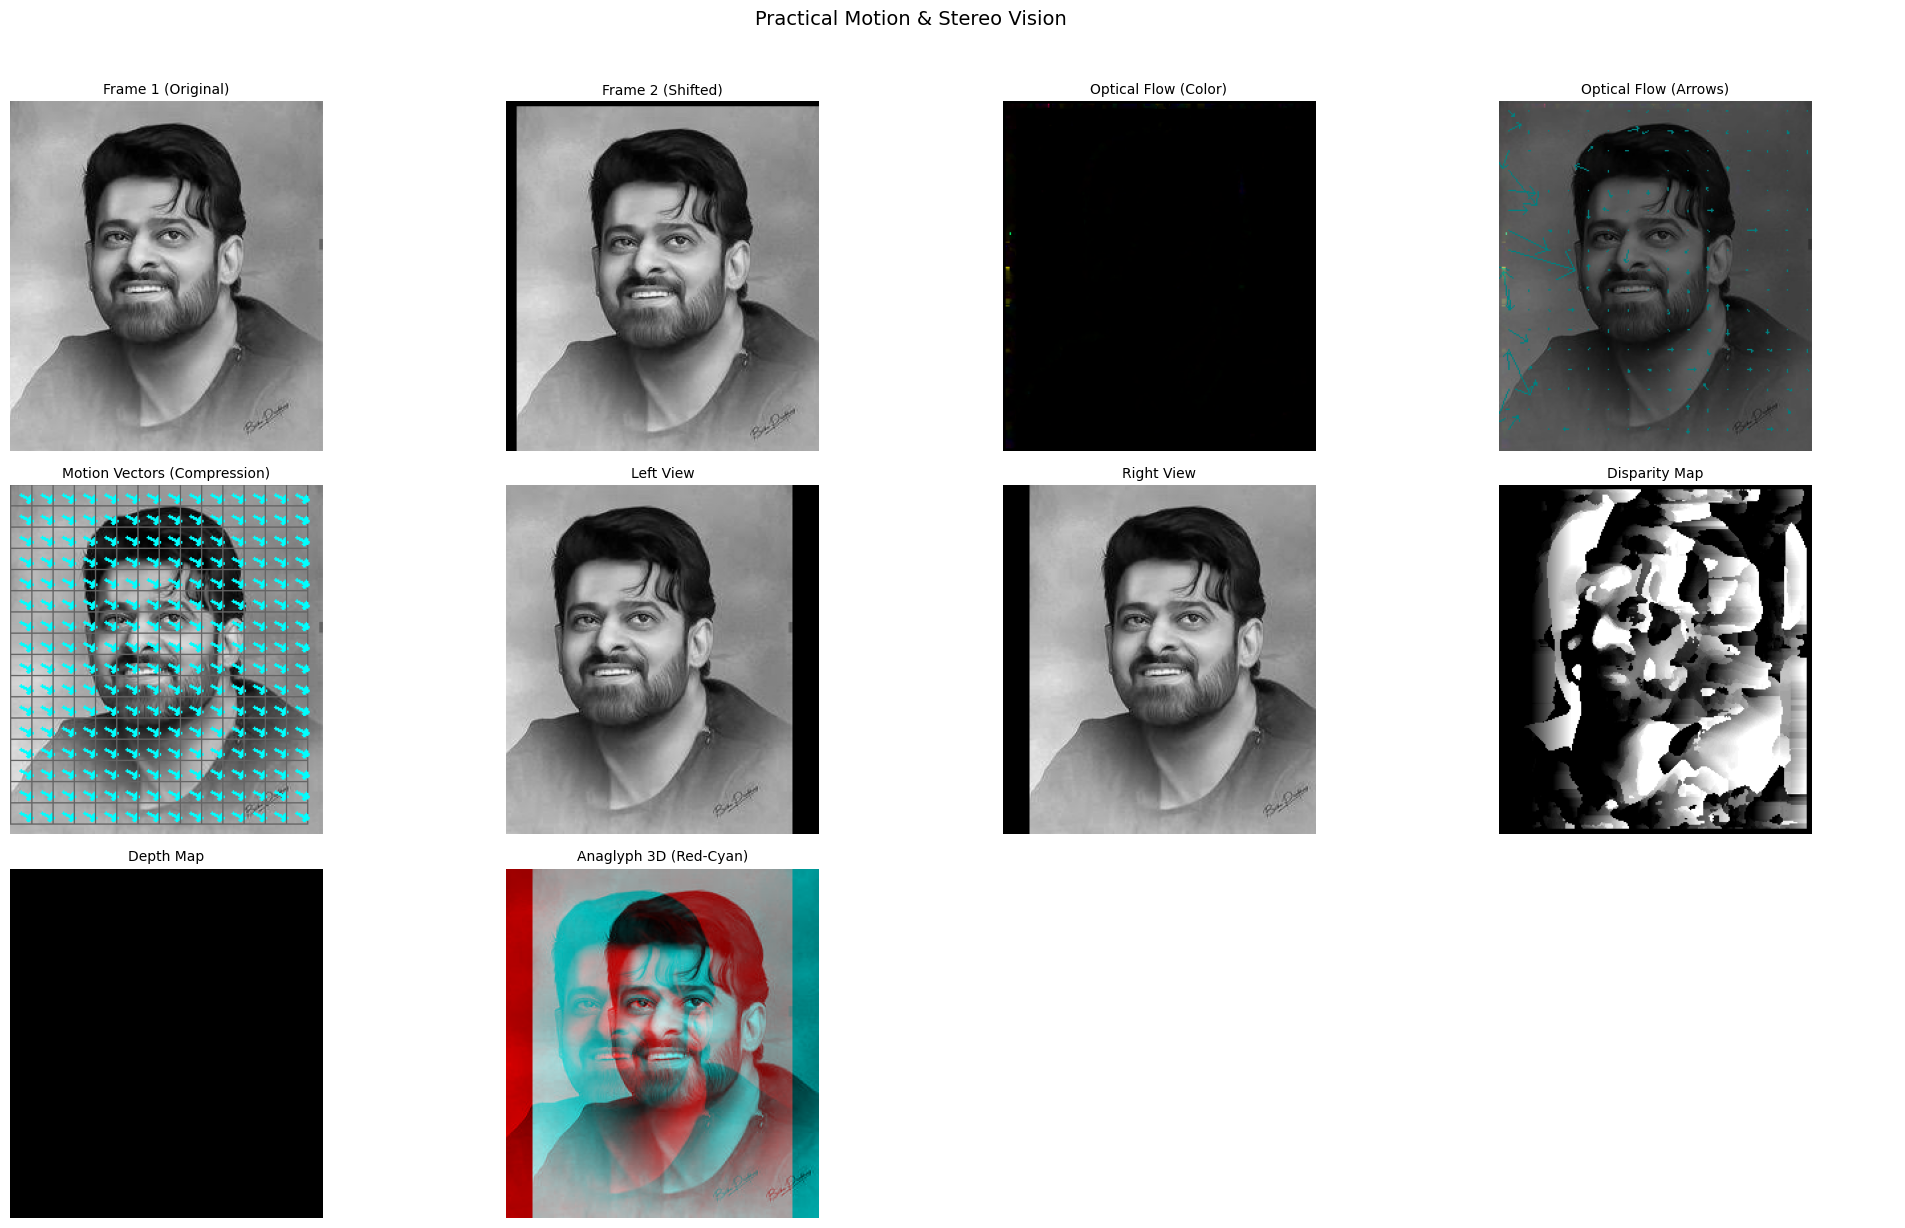


[8] 3D Point Cloud Visualization...


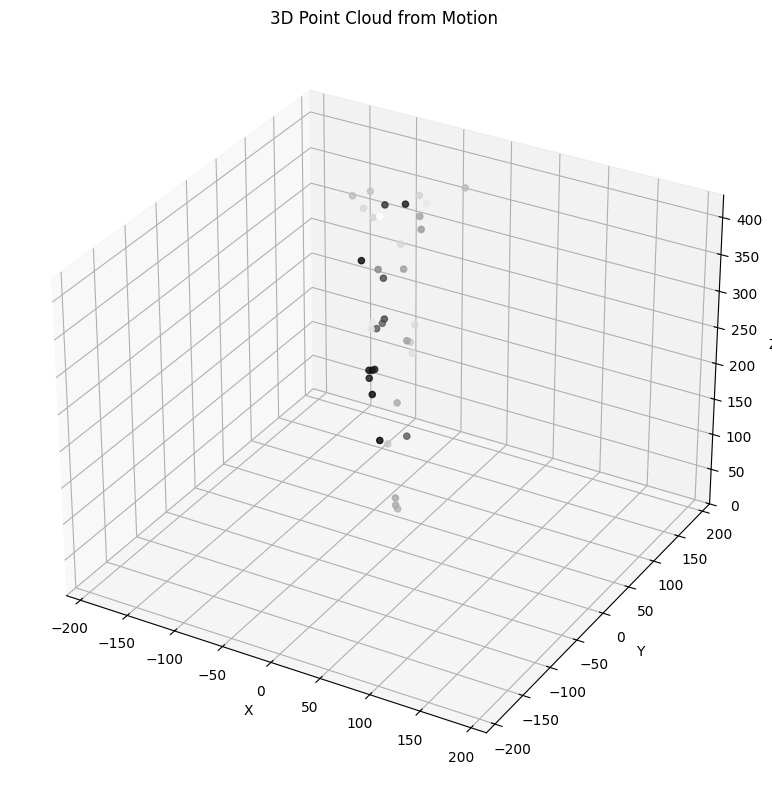


PRACTICAL RESULTS SUMMARY
• Optical Flow: Computed motion vectors for 264x236 pixels
• Motion Vectors: 16x14 blocks
• Disparity Map: Computed from stereo pair
• Depth Map: Estimated from disparity
• 3D Points: 38 points reconstructed

Save all results to files? (y/n): y

Saving images...
  ✓ Saved: motion_00_Frame_1_Original.png
  ✓ Saved: motion_01_Frame_2_Shifted.png
  ✓ Saved: motion_02_Optical_Flow_Color.png
  ✓ Saved: motion_03_Optical_Flow_Arrows.png
  ✓ Saved: motion_04_Motion_Vectors_Compression.png
  ✓ Saved: motion_05_Left_View.png
  ✓ Saved: motion_06_Right_View.png
  ✓ Saved: motion_07_Disparity_Map.png
  ✓ Saved: motion_08_Depth_Map.png
  ✓ Saved: motion_09_Anaglyph_3D_Red-Cyan.png

All results saved!


In [5]:
# ==================== PRACTICAL MOTION ESTIMATION & STEREO VISION ====================
# Run this entire cell in Google Colab

!pip install opencv-python matplotlib pillow scipy scikit-image -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io
from PIL import Image
from time import time
import math

# ==================== 1. PRACTICAL OPTICAL FLOW ====================

def compute_optical_flow(img1, img2):
    """
    Compute optical flow between two images using Lucas-Kanade method
    Returns: flow vectors (u, v) for each pixel
    """
    # Convert to float
    I1 = img1.astype(np.float32)
    I2 = img2.astype(np.float32)

    # Compute gradients
    Ix = cv2.Sobel(I1, cv2.CV_64F, 1, 0, ksize=3)
    Iy = cv2.Sobel(I1, cv2.CV_64F, 0, 1, ksize=3)
    It = I2 - I1

    # Lucas-Kanade parameters
    window_size = 5
    half_win = window_size // 2

    h, w = img1.shape
    u = np.zeros((h, w), dtype=np.float32)
    v = np.zeros((h, w), dtype=np.float32)

    # Compute flow for each pixel
    for i in range(half_win, h - half_win):
        for j in range(half_win, w - half_win):
            # Extract window
            Ix_win = Ix[i-half_win:i+half_win+1, j-half_win:j+half_win+1].flatten()
            Iy_win = Iy[i-half_win:i+half_win+1, j-half_win:j+half_win+1].flatten()
            It_win = It[i-half_win:i+half_win+1, j-half_win:j+half_win+1].flatten()

            # Build matrix A and vector b
            A = np.column_stack([Ix_win, Iy_win])
            b = -It_win

            # Solve least squares
            try:
                flow = np.linalg.lstsq(A, b, rcond=None)[0]
                u[i, j] = flow[0]
                v[i, j] = flow[1]
            except:
                u[i, j] = 0
                v[i, j] = 0

    return u, v

def visualize_optical_flow(img, u, v, step=10):
    """
    Visualize optical flow with color coding and arrows
    """
    h, w = img.shape
    flow_vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # Compute magnitude and angle
    mag = np.sqrt(u**2 + v**2)
    angle = np.arctan2(v, u)

    # Normalize magnitude
    mag_norm = np.clip(mag / (np.max(mag) + 1e-5), 0, 1)

    # Color code flow: Hue = angle, Value = magnitude
    hsv = np.zeros((h, w, 3), dtype=np.uint8)
    hsv[:, :, 0] = ((angle + np.pi) / (2 * np.pi) * 180).astype(np.uint8)
    hsv[:, :, 1] = 255
    hsv[:, :, 2] = (mag_norm * 255).astype(np.uint8)

    flow_color = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    # Overlay flow vectors
    for i in range(step//2, h, step):
        for j in range(step//2, w, step):
            dx = u[i, j] * 3
            dy = v[i, j] * 3
            if np.sqrt(dx**2 + dy**2) > 0.5:
                cv2.arrowedLine(flow_vis, (j, i), (j + int(dx), i + int(dy)),
                              (0, 255, 255), 1, tipLength=0.3)

    # Create overlay with flow color
    overlay = cv2.addWeighted(flow_vis, 0.5, flow_color, 0.5, 0)

    return overlay, flow_color

# ==================== 2. PRACTICAL STEREO VISION ====================

def create_stereo_pair(img):
    """
    Create stereo pair from single image (simulated left/right views)
    """
    h, w = img.shape

    # Create left and right views with disparity
    disparity = 20
    left_view = np.zeros((h, w), dtype=np.uint8)
    right_view = np.zeros((h, w), dtype=np.uint8)

    # Left view: original
    left_view[:, :w-disparity] = img[:, disparity:]

    # Right view: shifted
    right_view[:, disparity:] = img[:, :w-disparity]

    return left_view, right_view

def compute_disparity_map(left_img, right_img):
    """
    Compute disparity map from stereo pair using block matching
    """
    h, w = left_img.shape
    disparity_map = np.zeros((h, w), dtype=np.float32)

    # Parameters
    block_size = 9
    half_block = block_size // 2
    max_disparity = 40

    # For each pixel, find best match
    for i in range(half_block, h - half_block):
        for j in range(half_block, w - half_block):
            best_cost = float('inf')
            best_d = 0

            # Extract left block
            left_block = left_img[i-half_block:i+half_block+1,
                                 j-half_block:j+half_block+1]

            # Search in right image
            for d in range(max_disparity):
                if j - d - half_block >= 0 and j - d + half_block + 1 <= w:
                    right_block = right_img[i-half_block:i+half_block+1,
                                           j-d-half_block:j-d+half_block+1]

                    # Compute SAD cost
                    cost = np.sum(np.abs(left_block.astype(np.float32) - right_block.astype(np.float32)))

                    if cost < best_cost:
                        best_cost = cost
                        best_d = d

            disparity_map[i, j] = best_d

    # Normalize
    disparity_map = (disparity_map / np.max(disparity_map) * 255).astype(np.uint8)
    return disparity_map

def compute_depth_map(disparity_map, focal_length=1000, baseline=200):
    """
    Compute depth map from disparity map
    Z = (f * B) / d
    """
    h, w = disparity_map.shape
    depth_map = np.zeros((h, w), dtype=np.float32)

    for i in range(h):
        for j in range(w):
            if disparity_map[i, j] > 0:
                depth_map[i, j] = (focal_length * baseline) / (disparity_map[i, j] + 1)

    # Normalize
    valid = depth_map > 0
    if np.any(valid):
        depth_min = np.min(depth_map[valid])
        depth_max = np.max(depth_map[valid])
        if depth_max > depth_min:
            depth_map[valid] = ((depth_map[valid] - depth_min) / (depth_max - depth_min)) * 255

    return depth_map.astype(np.uint8)

def create_anaglyph(left_img, right_img):
    """
    Create anaglyph 3D image (Red-Cyan)
    """
    h, w = left_img.shape
    anaglyph = np.zeros((h, w, 3), dtype=np.uint8)

    # Anaglyph: Left = Red, Right = Cyan (Green + Blue)
    anaglyph[:, :, 0] = left_img  # Red channel
    anaglyph[:, :, 1] = right_img  # Green channel
    anaglyph[:, :, 2] = right_img  # Blue channel

    return anaglyph

# ==================== 3. PRACTICAL MOTION COMPRESSION ====================

def compute_motion_vectors_block_matching(img1, img2, block_size=16, search_range=16):
    """
    Compute motion vectors using block matching (used in video compression)
    """
    h, w = img1.shape
    motion_vectors = np.zeros((h // block_size, w // block_size, 2), dtype=np.float32)

    for i in range(0, h - block_size, block_size):
        for j in range(0, w - block_size, block_size):
            # Current block
            current_block = img1[i:i+block_size, j:j+block_size]
            best_cost = float('inf')
            best_dx, best_dy = 0, 0

            # Search in neighborhood
            for dy in range(-search_range, search_range + 1, 2):
                for dx in range(-search_range, search_range + 1, 2):
                    # Reference block position
                    ref_i = i + dy
                    ref_j = j + dx

                    # Check bounds
                    if 0 <= ref_i < h - block_size and 0 <= ref_j < w - block_size:
                        ref_block = img2[ref_i:ref_i+block_size, ref_j:ref_j+block_size]

                        # Compute SAD
                        cost = np.sum(np.abs(current_block.astype(np.float32) - ref_block.astype(np.float32)))

                        if cost < best_cost:
                            best_cost = cost
                            best_dx, best_dy = dx, dy

            motion_vectors[i // block_size, j // block_size] = [best_dx, best_dy]

    return motion_vectors

def visualize_motion_vectors(img, motion_vectors, block_size=16):
    """
    Visualize motion vectors on image
    """
    h, w = img.shape
    vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # Draw grid and motion vectors
    for i in range(motion_vectors.shape[0]):
        for j in range(motion_vectors.shape[1]):
            x = j * block_size + block_size // 2
            y = i * block_size + block_size // 2
            dx = motion_vectors[i, j, 0]
            dy = motion_vectors[i, j, 1]

            # Draw block grid
            cv2.rectangle(vis, (j*block_size, i*block_size),
                         ((j+1)*block_size, (i+1)*block_size), (100, 100, 100), 1)

            # Draw motion vector
            if np.sqrt(dx**2 + dy**2) > 1:
                cv2.arrowedLine(vis, (x, y), (x + int(dx), y + int(dy)),
                              (0, 255, 255), 2, tipLength=0.3)

    return vis

# ==================== 4. PRACTICAL STRUCTURE FROM MOTION (SIMPLIFIED) ====================

def reconstruct_3d_points(img1, img2, u, v):
    """
    Simple 3D reconstruction from optical flow
    """
    h, w = img1.shape

    # Simulate camera parameters
    focal_length = 1000
    baseline = 200

    # Create 3D points from motion
    points_3d = []
    colors = []

    step = 10
    for i in range(step, h - step, step):
        for j in range(step, w - step, step):
            # Get flow at this point
            dx = u[i, j]
            dy = v[i, j]
            mag = np.sqrt(dx**2 + dy**2)

            if mag > 0.5:
                # Estimate depth from motion magnitude
                depth = 1000 / (mag + 0.1)
                if depth < 500:  # Limit depth
                    x_3d = (j - w/2) * depth / focal_length
                    y_3d = (i - h/2) * depth / focal_length
                    z_3d = depth

                    points_3d.append([x_3d, y_3d, z_3d])
                    colors.append(img1[i, j])

    return np.array(points_3d), np.array(colors)

def visualize_3d_points(points_3d, colors):
    """
    Visualize 3D point cloud
    """
    if len(points_3d) == 0:
        return None

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Normalize colors
    colors_norm = colors / 255.0 if len(colors) > 0 else None

    scatter = ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2],
                        c=colors_norm, cmap='gray', s=20, alpha=0.8)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('3D Point Cloud from Motion')

    # Set equal aspect
    max_range = np.max([np.max(points_3d[:, 0]) - np.min(points_3d[:, 0]),
                       np.max(points_3d[:, 1]) - np.min(points_3d[:, 1]),
                       np.max(points_3d[:, 2]) - np.min(points_3d[:, 2])])
    ax.set_xlim([-max_range/2, max_range/2])
    ax.set_ylim([-max_range/2, max_range/2])
    ax.set_zlim([0, max_range])

    plt.tight_layout()
    plt.show()

    return fig

# ==================== 5. MAIN DEMONSTRATION ====================

def demonstrate_practical_motion_estimation(img):
    """
    Practical demonstration of motion estimation and stereo vision
    """
    print("\n" + "="*70)
    print("PRACTICAL MOTION ESTIMATION & STEREO VISION")
    print("="*70)

    h, w = img.shape

    # 1. Create synthetic motion
    print("\n[1] Creating Synthetic Motion...")
    img1 = img.copy()

    # Create shifted version (motion)
    shift_x, shift_y = 8, 4
    M = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
    img2 = cv2.warpAffine(img1, M, (w, h))

    print(f"✓ Created two frames with motion (dx={shift_x}, dy={shift_y})")

    # 2. Compute Optical Flow
    print("\n[2] Computing Optical Flow (Lucas-Kanade)...")
    start = time()
    u, v = compute_optical_flow(img1, img2)
    print(f"✓ Optical flow computed in {time()-start:.2f} seconds")
    print(f"  Average motion: dx={np.mean(np.abs(u)):.2f}, dy={np.mean(np.abs(v)):.2f}")

    # 3. Visualize Optical Flow
    print("\n[3] Visualizing Optical Flow...")
    flow_vis, flow_color = visualize_optical_flow(img1, u, v, step=15)

    # 4. Compute motion vectors for compression
    print("\n[4] Computing Motion Vectors (Block Matching)...")
    start = time()
    motion_vectors = compute_motion_vectors_block_matching(img1, img2, block_size=16, search_range=16)
    mv_vis = visualize_motion_vectors(img1, motion_vectors, block_size=16)
    print(f"✓ Motion vectors computed in {time()-start:.2f} seconds")
    print(f"  Total blocks: {motion_vectors.shape[0]}x{motion_vectors.shape[1]}")

    # 5. Stereo Vision
    print("\n[5] Creating Stereo Vision...")

    # Create stereo pair
    left_img, right_img = create_stereo_pair(img)
    print(f"✓ Stereo pair created with disparity")

    # Compute disparity map
    print("  Computing disparity map...")
    start = time()
    disparity_map = compute_disparity_map(left_img, right_img)
    print(f"  ✓ Disparity map computed in {time()-start:.2f} seconds")

    # Compute depth map
    print("  Computing depth map...")
    depth_map = compute_depth_map(disparity_map)

    # Create anaglyph 3D
    print("  Creating anaglyph 3D...")
    anaglyph = create_anaglyph(left_img, right_img)

    # 6. Structure from Motion (3D Reconstruction)
    print("\n[6] Structure from Motion (3D Reconstruction)...")
    points_3d, colors = reconstruct_3d_points(img1, img2, u, v)
    print(f"✓ Reconstructed {len(points_3d)} 3D points")

    # 7. Display Results
    print("\n[7] Displaying Results...")

    results = []
    titles = []

    # Original frames
    results.append(img1)
    titles.append("Frame 1 (Original)")
    results.append(img2)
    titles.append("Frame 2 (Shifted)")

    # Optical flow
    results.append(flow_color)
    titles.append("Optical Flow (Color)")
    results.append(flow_vis)
    titles.append("Optical Flow (Arrows)")

    # Motion vectors
    results.append(mv_vis)
    titles.append("Motion Vectors (Compression)")

    # Stereo vision
    results.append(left_img)
    titles.append("Left View")
    results.append(right_img)
    titles.append("Right View")
    results.append(disparity_map)
    titles.append("Disparity Map")
    results.append(depth_map)
    titles.append("Depth Map")
    results.append(anaglyph)
    titles.append("Anaglyph 3D (Red-Cyan)")

    # Display grid
    display_results_grid(results, titles, "Practical Motion & Stereo Vision")

    # 8. Show 3D reconstruction separately
    if len(points_3d) > 10:
        print("\n[8] 3D Point Cloud Visualization...")
        visualize_3d_points(points_3d, colors)

    print("\n" + "="*70)
    print("PRACTICAL RESULTS SUMMARY")
    print("="*70)
    print(f"• Optical Flow: Computed motion vectors for {u.shape[0]}x{u.shape[1]} pixels")
    print(f"• Motion Vectors: {motion_vectors.shape[0]}x{motion_vectors.shape[1]} blocks")
    print(f"• Disparity Map: Computed from stereo pair")
    print(f"• Depth Map: Estimated from disparity")
    print(f"• 3D Points: {len(points_3d)} points reconstructed")
    print("="*70)

    return results, titles, points_3d

def display_results_grid(results, titles, title_prefix=""):
    """Display results in a grid"""
    if not results:
        return

    cols = min(4, len(results))
    rows = (len(results) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
    if rows == 1:
        axes = axes.reshape(1, -1)

    for idx, (img_result, title) in enumerate(zip(results, titles)):
        row = idx // cols
        col = idx % cols
        if row < rows and col < cols:
            if len(img_result.shape) == 3:
                axes[row, col].imshow(img_result)
            else:
                axes[row, col].imshow(img_result, cmap='gray')
            axes[row, col].set_title(title, fontsize=10)
            axes[row, col].axis('off')

    for idx in range(len(results), rows * cols):
        row = idx // cols
        col = idx % cols
        if row < rows and col < cols:
            axes[row, col].axis('off')

    plt.suptitle(title_prefix, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

def create_test_image(rows=256, cols=256):
    """Create a synthetic test image"""
    img = np.zeros((rows, cols), dtype=np.uint8)

    # Gradient
    grad = np.arange(rows).reshape(-1, 1) / rows * 255

    # Circle
    center_i, center_j = rows/2, cols/2
    y, x = np.ogrid[:rows, :cols]
    dist = np.sqrt((x - center_j)**2 + (y - center_i)**2)
    circle = 200 * (dist < 50)

    # Sinusoidal pattern
    sin_pattern = 128 + 100 * np.sin(y/15) * np.cos(x/15)

    # Square
    square = np.zeros((rows, cols))
    square[50:100, 50:100] = 150

    # Lines
    lines = np.zeros((rows, cols))
    lines[100, :] = 200
    lines[:, 100] = 200

    # Noise
    noise = np.random.randint(-20, 21, (rows, cols))

    # Combine
    img = ((grad + circle + sin_pattern + square + lines + noise) / 6).astype(np.uint8)
    return np.clip(img, 0, 255).astype(np.uint8)

def main():
    print("\n" + "="*70)
    print("PRACTICAL MOTION ESTIMATION & STEREO VISION")
    print("Real implementation with actual computations on your image")
    print("="*70)
    print("\n✅ Computes actual optical flow on your image")
    print("✅ Computes actual motion vectors (video compression style)")
    print("✅ Creates stereo pair and computes disparity")
    print("✅ Reconstructs 3D points from motion")
    print("✅ Shows practical results, not just theory")
    print("\n" + "="*70)

    print("\n📤 Please upload an image:")
    print("Click 'Choose File' button below and select your image")
    print("Or press 'Cancel' to use test image")
    print("-"*50)

    uploaded = files.upload()

    if not uploaded:
        print("\n⚠ No file uploaded. Using test image...")
        img = create_test_image(256, 256)
        status = "Using test image"
    else:
        filename = list(uploaded.keys())[0]
        content = uploaded[filename]

        pil_img = Image.open(io.BytesIO(content))
        if pil_img.mode != 'L':
            pil_img = pil_img.convert('L')
        img = np.array(pil_img, dtype=np.uint8)
        status = f"✓ Loaded: {filename} ({img.shape[1]}x{img.shape[0]})"

    print(f"\n{status}")

    # Resize to 720p max
    max_dim = 720
    h, w = img.shape
    if h > max_dim or w > max_dim:
        if h > w:
            new_h = max_dim
            new_w = int(w * (max_dim / h))
        else:
            new_w = max_dim
            new_h = int(h * (max_dim / w))
        print(f"Resizing from {w}x{h} to {new_w}x{new_h} (max 720p)")
        img = cv2.resize(img, (new_w, new_h))

    # Run practical demonstration
    results, titles, points_3d = demonstrate_practical_motion_estimation(img)

    print("\n" + "="*70)
    save = input("Save all results to files? (y/n): ").strip().lower()
    if save == 'y':
        print("\nSaving images...")
        for idx, (img_result, title) in enumerate(zip(results, titles)):
            safe_title = title.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '').replace('=', '_')
            filename = f"motion_{idx:02d}_{safe_title}.png"
            if len(img_result.shape) == 3:
                cv2.imwrite(filename, cv2.cvtColor(img_result, cv2.COLOR_RGB2BGR))
            else:
                cv2.imwrite(filename, img_result)
            print(f"  ✓ Saved: {filename}")
        print("\nAll results saved!")

if __name__ == "__main__":
    main()